In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import scipy as sc
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu
import scipy.stats as stats

In [2]:
ROOT = '../data/processed/'
PATH_UNET_MLP_MODEL_NOISE_0 = ROOT+'2025_results_noise0_unetmlp/'
PATH_UNET_MLP_MODEL_NOISE_20 =  ROOT+'2025_results_noise20_unetmlp/'

In [3]:
# Variables
variable_names={"temperature",
            "pH",
            "sodium",
            "glucose"}

In [4]:
for value in variable_names:
    df= pd.read_csv(PATH_UNET_MLP_MODEL_NOISE_0+"model_unet_mlp_model_{}_noise0_2025.csv".format(value))
    print(value.upper())

PH
SODIUM
GLUCOSE
TEMPERATURE


In [5]:
value = 'glucose'
# UNET zero
df_unet_zero = pd.read_csv(PATH_UNET_MLP_MODEL_NOISE_0+"model_unet_mlp_model_{}_noise0_2025.csv".format(value))

# UNET noise
df_unet_noise= pd.read_csv(PATH_UNET_MLP_MODEL_NOISE_20+"model_unet_mlp_model_{}_noise20_2025.csv".format(value))


if value=='temperature':
    df_unet_zero = df_unet_zero[df_unet_zero['target_array_real'].between(35.5, 39)]
    df_unet_noise = df_unet_noise[df_unet_noise['target_array_real'].between(35.5, 39)]  

# Errors
df_unet_zero['pred_error']=np.abs(df_unet_zero['target_array_real']-df_unet_zero['pred_array_real'])
unet_zero_pred_error = np.abs(df_unet_zero['pred_error'].to_numpy())

df_unet_noise['pred_error']=np.abs(df_unet_noise['target_array_real']-df_unet_noise['pred_array_real'])
unet_noise_pred_error = np.abs(df_unet_noise['pred_error'].to_numpy())

# find average error per label
grouped_df_unet_zero = df_unet_zero.groupby('target_array_real').mean().reset_index()
grouped_df_unet_noise = df_unet_noise.groupby('target_array_real').mean().reset_index()


pred_error_paired = np.abs(grouped_df_unet_zero['pred_error'] - grouped_df_unet_noise['pred_error'])

In [6]:
alpha = 0.95

mean = np.mean(pred_error_paired)
sem = stats.sem(pred_error_paired)  # Standard error of the mean
df = len(pred_error_paired) - 1

print(f"mean: {mean}")
print(f"SD: {np.std(pred_error_paired)}")

ci = stats.t.interval(confidence=alpha, df=df, loc=mean, scale=sem)
print(f"95% Confidence Interval: {ci}")



mean: 0.006719136391005624
SD: 0.005046408881834993
95% Confidence Interval: (0.0009177890516993657, 0.012520483730311883)


In [7]:
grouped_df_unet_zero

,target_array_real,target_0_1,pred_0_1,pred_array_real,pred_error
0,0.000,0.090909,0.086367,-0.003150,0.009200
1,0.040,0.149091,0.155910,0.044714,0.009524
2,0.080,0.207273,0.202713,0.076857,0.012929
3,0.160,0.323636,0.318114,0.156171,0.014317
4,0.312,0.545455,0.526656,0.299595,0.036243
5,0.625,1.000000,0.959828,0.597423,0.027577


In [8]:
grouped_df_unet_noise

,target_array_real,target_0_1,pred_0_1,pred_array_real,pred_error
0,0.000,0.090909,0.105841,0.010231,0.018385
1,0.040,0.149091,0.150051,0.040676,0.009270
2,0.080,0.207273,0.209151,0.081265,0.011755
3,0.160,0.323636,0.331411,0.165324,0.029559
4,0.312,0.545455,0.531994,0.303318,0.044182
5,0.625,1.000000,0.969478,0.603946,0.021054


pH
U-Net MAE: 0.46720833333333334
U-Net SD: 0.3755339286898352
pH
Mean - Paired Difference by Label: 0.0729
SD - Paired Difference by Label: 0.05434653796013706
95% Confidence Interval: 1.87e-02
95% Confidence Interval: 1.27e-01
DIFFERENCE NORMAL vs NOISY - overall means 0.0517


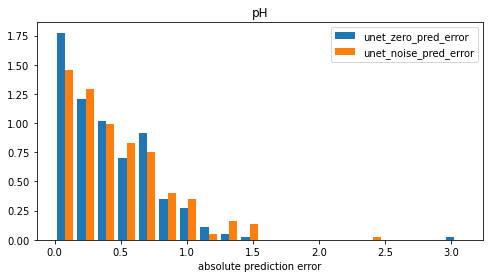

240
240
sodium
U-Net MAE: 0.8480583333333332
U-Net SD: 0.6720597232368729
sodium
Mean - Paired Difference by Label: 0.0582
SD - Paired Difference by Label: 0.04195851461758344
95% Confidence Interval: -1.86e-05
95% Confidence Interval: 1.16e-01
DIFFERENCE NORMAL vs NOISY - overall means 0.00845


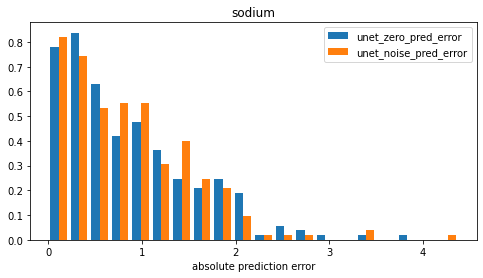

240
240
glucose
U-Net MAE: 0.022350000000000002
U-Net SD: 0.029443066529603643
glucose
Mean - Paired Difference by Label: 0.00672
SD - Paired Difference by Label: 0.005046408881834993
95% Confidence Interval: 9.18e-04
95% Confidence Interval: 1.25e-02
DIFFERENCE NORMAL vs NOISY - overall means 0.00363


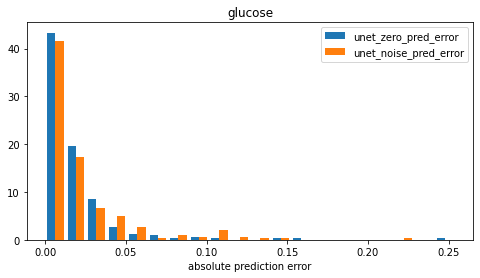

240
240
temperature
U-Net MAE: 0.4793319502074692
U-Net SD: 0.39699524670787256
temperature
Mean - Paired Difference by Label: 0.0381
SD - Paired Difference by Label: 0.04278709439525746
95% Confidence Interval: -9.36e-05
95% Confidence Interval: 7.64e-02
DIFFERENCE NORMAL vs NOISY - overall means 0.0243


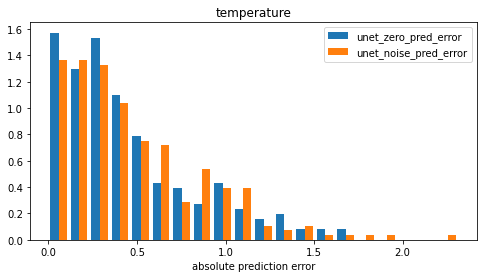

220
241


In [9]:
# Variable
for value in variable_names:
    
    # UNET zero
    df_unet_zero = pd.read_csv(PATH_UNET_MLP_MODEL_NOISE_0+"model_unet_mlp_model_{}_noise0_2025.csv".format(value))
    
    # UNET noise
    df_unet_noise= pd.read_csv(PATH_UNET_MLP_MODEL_NOISE_20+"model_unet_mlp_model_{}_noise20_2025.csv".format(value))
    
    
    if value=='temperature':
        df_unet_zero = df_unet_zero[df_unet_zero['target_array_real'].between(35.5, 39)]
        df_unet_noise = df_unet_noise[df_unet_noise['target_array_real'].between(35.5, 39)]  

    # Errors
    df_unet_zero['pred_error']=np.abs(df_unet_zero['target_array_real']-df_unet_zero['pred_array_real'])
    unet_zero_pred_error = np.abs(df_unet_zero['pred_error'].to_numpy())

    df_unet_noise['pred_error']=np.abs(df_unet_noise['target_array_real']-df_unet_noise['pred_array_real'])
    unet_noise_pred_error = np.abs(df_unet_noise['pred_error'].to_numpy())
    
    print(value)
    print('U-Net MAE:',np.mean(unet_noise_pred_error))
    print('U-Net SD:',np.std(unet_noise_pred_error))
    

    # find average error per label
    grouped_df_unet_zero = df_unet_zero.groupby('target_array_real').mean().reset_index()
    grouped_df_unet_noise = df_unet_noise.groupby('target_array_real').mean().reset_index()
    
    
    # Paired Error
    pred_error_paired = np.abs(grouped_df_unet_zero['pred_error'] - grouped_df_unet_noise['pred_error'])
    
    alpha = 0.95

    mean = np.mean(pred_error_paired)
    sem = stats.sem(pred_error_paired)  # Standard error of the mean
    dof = len(pred_error_paired) - 1

    print(value)
    print(f"Mean - Paired Difference by Label: {mean:.3}")
    print(f"SD - Paired Difference by Label: {np.std(pred_error_paired)}")

    ci = stats.t.interval(confidence=alpha, df=dof, loc=mean, scale=sem)
    print(f"95% Confidence Interval: {ci[0]:.2e}")
    print(f"95% Confidence Interval: {ci[1]:.2e}")

    # Print 
    # difference of the means
    mean_diff = np.abs(np.mean(unet_zero_pred_error) - np.mean(unet_noise_pred_error))
    print(f'DIFFERENCE NORMAL vs NOISY - overall means {mean_diff:.3}')
 
    # Plot for Variable 
    plt.figure(figsize=(8, 4))
    plt.title(value)
    plt.xlabel('absolute prediction error')
    plt.hist([unet_zero_pred_error, unet_noise_pred_error], bins=20, label=["unet_zero_pred_error","unet_noise_pred_error"], density=True)
    plt.legend(loc="upper right")
    plt.show()
    
    print(len(unet_zero_pred_error))
    print(len(unet_noise_pred_error))
    


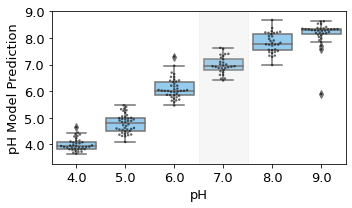

In [54]:
value='pH'
path_root = PATH_UNET_MLP_MODEL_NOISE_0
# Unet
df_results_complete= pd.read_csv(path_root+"model_unet_mlp_model_{}_noise0_2025.csv".format(value))
ylabel='pred_array_real'

# Plot violin
fig = plt.figure(figsize=(5,3))

sns.boxplot(
    data=df_results_complete,
    x="target_array_real",
    y=ylabel,
    # width=1.1
    color='lightskyblue',
)
sns.swarmplot(
    data=df_results_complete,
    x="target_array_real",
    y=ylabel,
    size=2.5,
    color='black',
    alpha=0.6,
    # width=1.1
    # color='thistle',
)

plt.yticks(
    [4, 5, 6, 7, 8, 9],
    [4.0, 5.0, 6.0, 7.0, 8.0, 9.0],
    fontsize=13,
)

plt.xticks(fontsize=13)

plt.axvspan(3.5, 4.5, color='lightgray', alpha=0.2)

plt.xlim([0.5,6.5])

plt.xlabel('pH',fontsize=13)
plt.ylabel('pH Model Prediction',fontsize=13)
plt.tight_layout()
plt.savefig('ph_figure.pdf')

In [ ]:
# pH
# plt.axvspan(3.5, 4.5, color='lightgray', alpha=0.4)
# plt.xlabel('pH', fontsize=LETTER_SIZE)
# plt.ylabel('pH Model Prediction', fontsize=LETTER_SIZE)
#
# plt.text(-0.2, 8.5, "MAE=0.416", fontsize=LETTER_SIZE)
#
# plt.yticks(
#     [3, 4, 5, 6, 7, 8, 9],
#     [3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0],
#     fontsize=LETTER_SIZE,
# )
#
# plt.xticks(fontsize=LETTER_SIZE)
# # lightskyblue